In [1]:
from importlib.metadata import version, PackageNotFoundError
import matplotlib
import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
pd.set_option("display.max_columns", 100)
import seaborn as sns
from sklearn.model_selection import train_test_split

Ссылка на датасет: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

#### Поля датасета

|Значение | Описание|
|----------|-----------|
|customerID | ID клиента|
|gender | Является ли клиент мужчиной или женщиной|
|SeniorCitizen | Является ли клиент пожилым человеком или нет (1, 0)|
|Partner | Есть ли у клиента партнер или нет (Yes, No)|
|Dependents | Есть ли у клиента иждивенцы или нет (Yes, No)|
|tenure | Количество месяцев, в течение которых клиент проработал в компании|
|PhoneService | Есть ли у клиента телефонная связь или нет (Yes, No)|
|MultipleLines | Есть ли у клиента несколько линий или нет (Yes, No, No phone service)|
|InternetService | Интернет-провайдер клиента (DSL, Fiber optic, No)|
|OnlineSecurity | Есть ли у клиента онлайн-безопасность или нет (Yes, No, No internet service)|
|OnlineBackup |  Есть ли у клиента онлайн-резервное копирование или нет (Yes, No, No internet service|)
|DeviceProtection |  Есть ли у клиента защита устройства или нет (Yes, No, No internet service)|
|TechSupport |  Есть ли у клиента техническая поддержка или нет (Yes, No, No internet service)|
|StreamingTV |  Есть ли у клиента потоковое телевидение или нет (Yes, No, No internet service)|
|StreamingMovies |  Есть ли у клиента потоковое видео или нет (Yes, No, No internet service)|
|Contract |  Срок действия договора заказчика (Month-to-month, One year, Two year)|
|PaperlessBilling |  Есть ли у клиента безбумажный счет или нет (Yes, No)|
|PaymentMethod |  Способ оплаты клиента (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic))|
|MonthlyCharges |  Сумма, взимаемая с клиента ежемесячно|
|TotalCharges |  Общая сумма, взимаемая с клиента|
|Churn |  Ушел ли клиент или нет (Yes or No)|

### Загрузка данных

In [2]:
df = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df = df.drop(columns='customerID')
df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


### EDA

In [4]:
print(f"Строк: {len(df)}, Столбцов: {len(df.columns)}")  

Строк: 7043, Столбцов: 20


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

#### Анализ числовых признаков

In [6]:
# Анализ числовых признаков
df_num_features = df.select_dtypes(include=['float64', 'int64'])
df_num_features.head()

,SeniorCitizen,tenure,MonthlyCharges
0,0,1,29.85
1,0,34,56.95
2,0,2,53.85
3,0,45,42.30
4,0,2,70.70


In [7]:
df_num_features.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [8]:
df_num_features = df_num_features.drop(columns='SeniorCitizen')

In [9]:
# Поиск выбросов с помощью IQR

Q1 = df_num_features[df_num_features.columns].quantile(0.25)
Q3 = df_num_features[df_num_features.columns].quantile(0.75)
IQR = Q3 - Q1

# Создаём DataFrame с флагами выбросов (True/False)
outlier_flags_train = ((df_num_features[df_num_features.columns] < (Q1 - 1.5 * IQR)) |
                       (df_num_features[df_num_features.columns] > (Q3 + 1.5 * IQR)))

# Пример: вывести % выбросов по колонкам
outlier_percent = outlier_flags_train.mean().sort_values(ascending=False)
print("Процент выбросов по признакам:")
outlier_percent

Процент выбросов по признакам:


tenure            0.0
MonthlyCharges    0.0
dtype: float64

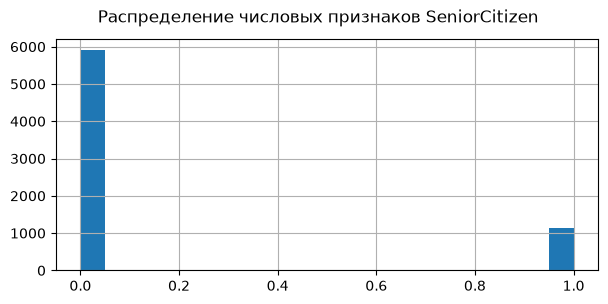

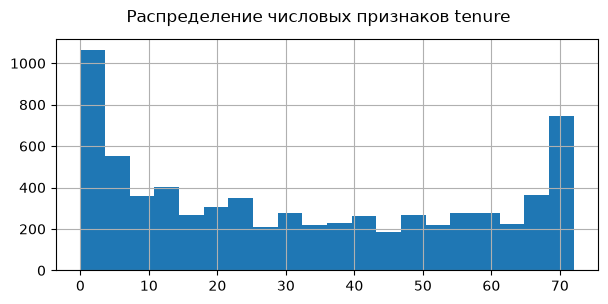

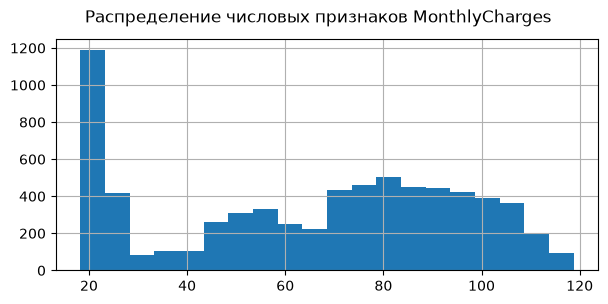

In [10]:
# Гистограммы числовых признаков
num_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges']

for col in num_cols:
    df[col].hist(bins=20, figsize=(7, 3))
    plt.suptitle(f'Распределение числовых признаков {col}')
    plt.show()

In [11]:
print(f'Доля пожилых в базе: {int(df['SeniorCitizen'].sum() / df['Churn'].count() * 100)}%')

Доля пожилых в базе: 16%


Выводы:
- Пожилые люди массово уходят, но доля пожилых в базе небольшая - 16%.
- Чем больше месяцев клиент проработал с компанией, тем ниже вероятность ухода.
- Чем выше ежемесячный платеж, тем выше вероятность ухода. 

#### Анализ категориальных признаков

In [12]:
# Анализ категориальных признаков
df_obj_features = df.select_dtypes(include=['str'])
df_obj_features.head(3)

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
0,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,No
1,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,1889.5,No
2,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,108.15,Yes


In [13]:
df_obj_features.describe().T

,count,unique,top,freq
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095
TechSupport,7043,3,No,3473


In [14]:
df_obj_features['InternetService'].unique()

<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

In [15]:
df_obj_features['StreamingMovies'].unique()

<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

In [16]:
df_obj_features['Contract'].unique()

<StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str

In [17]:
df_obj_features['PaymentMethod'].unique()

<StringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str

In [18]:
df_obj_features['TotalCharges'].sample(3)

3017    1087.45
1233     1685.9
4439     487.95
Name: TotalCharges, dtype: str

In [19]:
df_obj_features.columns.drop(['Churn', 'TotalCharges']).to_list()

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

#### Проверка пропущенных значений

In [20]:
df.isna().sum() # Пропусков нет

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

<Axes: >

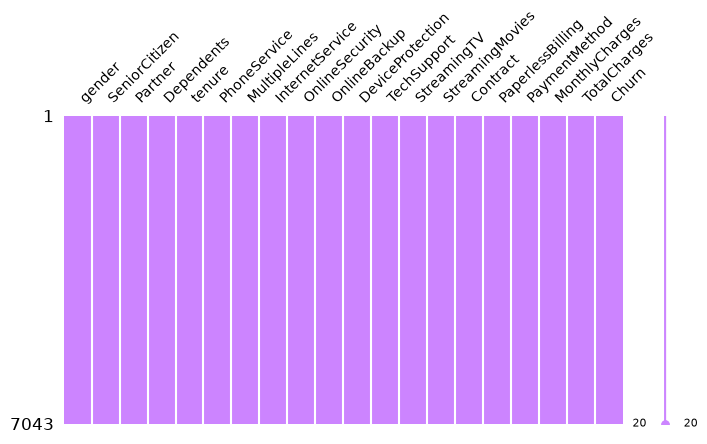

In [21]:
# Визуализация пропущенных значений
msno.matrix(df,figsize=(8,4), fontsize=10, color=(0.8, 0.52, 1.0))

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

TotalCharges ошибочно в str

In [23]:
# TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print('Пустых TotalCharges:', df['TotalCharges'].isna().sum())

Пустых TotalCharges: 11


In [24]:
df[df['TotalCharges'].isna()][['tenure', 'MonthlyCharges', 'Churn']]

,tenure,MonthlyCharges,Churn
488,0,52.55,No
753,0,20.25,No
936,0,80.85,No
1082,0,25.75,No
1340,0,56.05,No
3331,0,19.85,No
3826,0,25.35,No
4380,0,20.00,No
5218,0,19.70,No
6670,0,73.35,No


tenure = 0. Новые клиенты, еще не платили. 

In [25]:
# Заполняем пропуски: ежемесячный платеж на количество месяцев получения услуг
df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'] * df['tenure'])

#### Анализ целевой переменной

In [26]:
# Анализ целевой переменной 
df['Churn'].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [27]:
dict_Churn = {'No':0, 'Yes':1}
df['int_Churn'] = df['Churn'].map(dict_Churn)

In [28]:
df = df.drop(columns='Churn')
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,int_Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


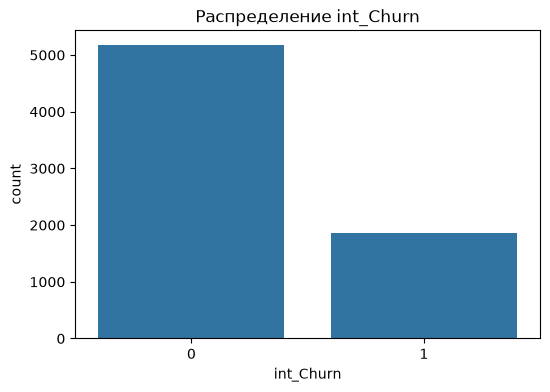


Распределение int_Churn:
int_Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


In [29]:
# Распределение целевой переменной
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='int_Churn')
plt.title('Распределение int_Churn')
plt.show()

print("\nРаспределение int_Churn:")
print(df['int_Churn'].value_counts(normalize=True))

Дисбаланс классов. 27% класса 1 ("Yes") против 73% класса 0 ("No").

#### Корреляционный анализ

<Axes: >

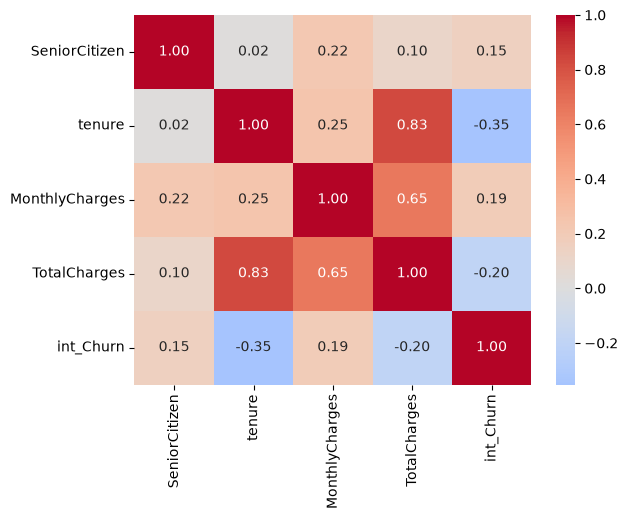

In [30]:
num_cols_corr = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'int_Churn']
sns.heatmap(df[num_cols_corr].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)

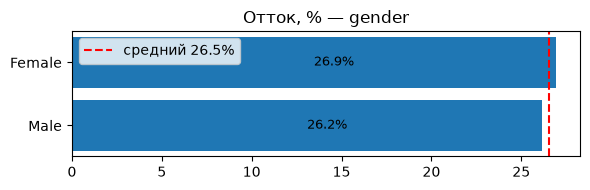

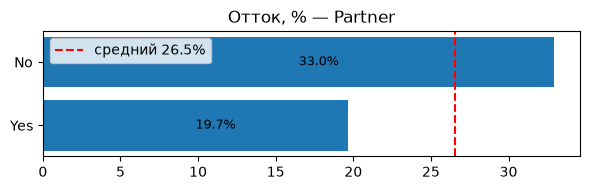

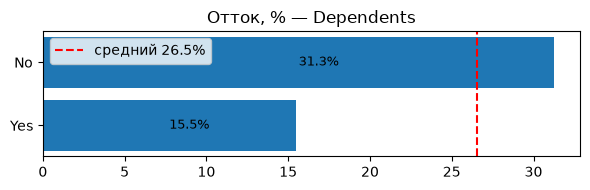

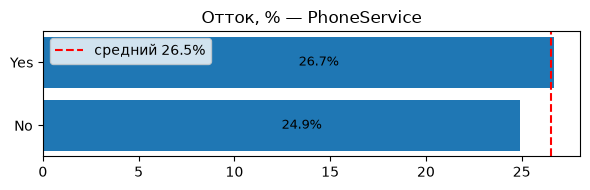

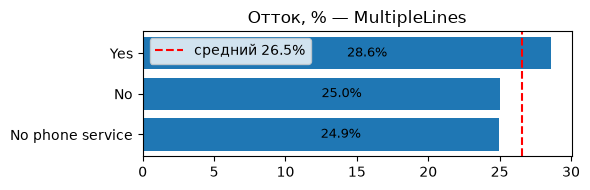

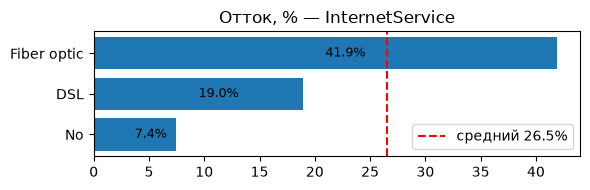

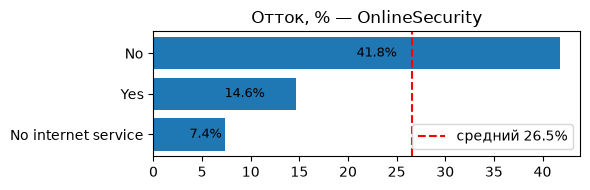

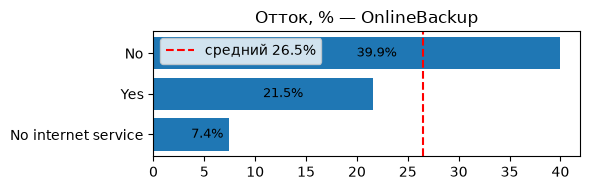

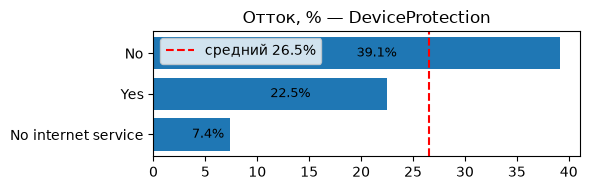

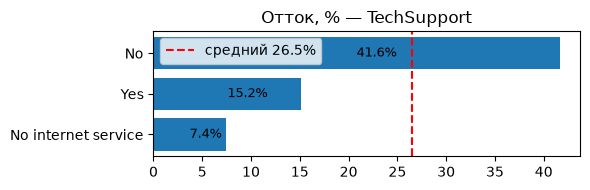

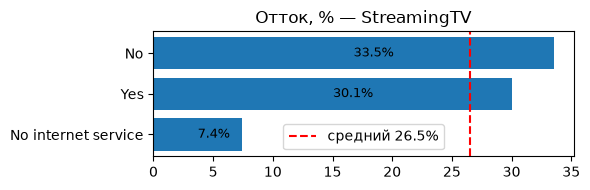

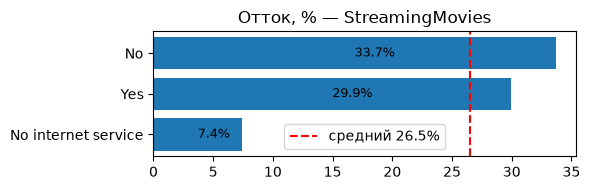

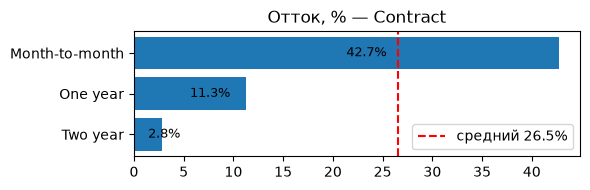

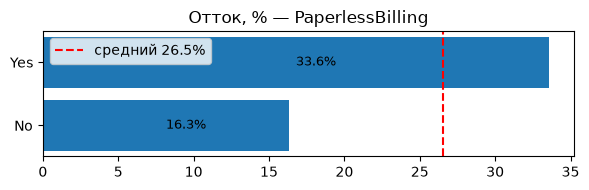

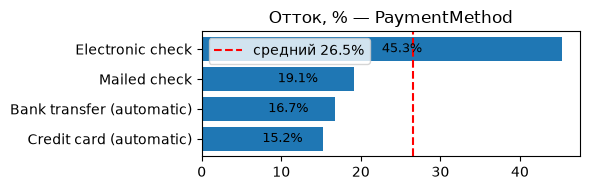

In [31]:
# Категориальные признаки
cat_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod']

for col in cat_cols:
    rate = df.groupby(col)['int_Churn'].mean().mul(100).sort_values()
    fig, ax = plt.subplots(figsize=(6, max(2, len(rate) * 0.4)))
    bars = ax.barh(rate.index.astype(str), rate.values)
    for bar, val in zip(bars, rate.values):
        ax.text(val / 2, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9)
    ax.axvline(df['int_Churn'].mean()*100, color='red', ls='--',
               label=f'средний {df["int_Churn"].mean()*100:.1f}%')
    ax.set_title(f'Отток, % — {col}')
    ax.legend()
    plt.tight_layout()
    plt.show()

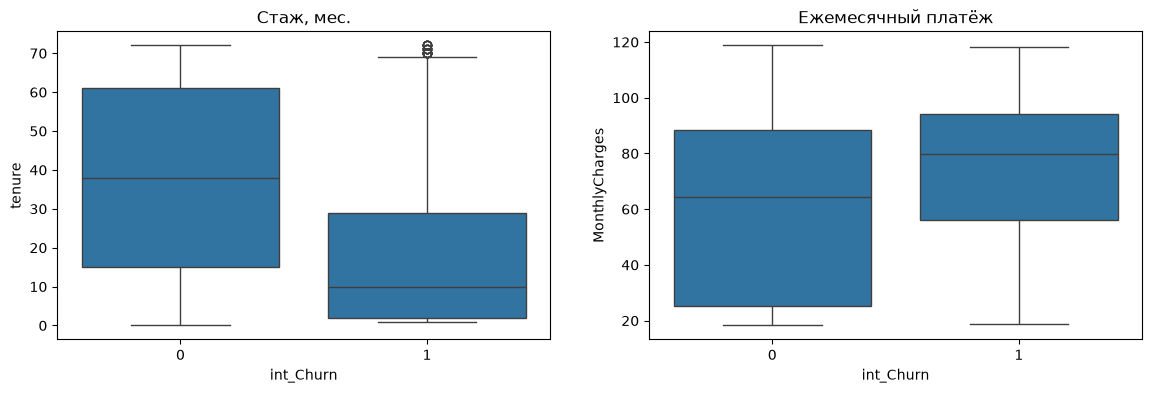

In [32]:
# Стаж и платежи: ушедшие vs оставшиеся
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=df, x='int_Churn', y='tenure', ax=axes[0]).set_title('Стаж, мес.')
sns.boxplot(data=df, x='int_Churn', y='MonthlyCharges', ax=axes[1]).set_title('Ежемесячный платёж')
plt.show()

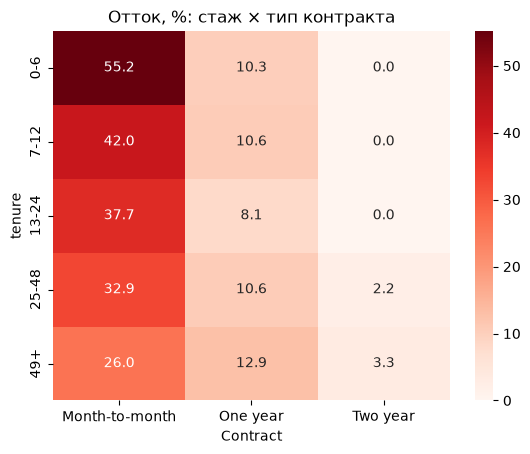

In [33]:
# Комбинация двух факторов: tenure, Contract
piv = df.pivot_table(index=pd.cut(df['tenure'], [-1, 6, 12, 24, 48, 100],
                                  labels=['0-6', '7-12', '13-24', '25-48', '49+']),
                     columns='Contract', values='int_Churn', aggfunc='mean').mul(100).round(1)
sns.heatmap(piv, annot=True, fmt='.1f', cmap='Reds')
plt.title('Отток, %: стаж × тип контракта')
plt.show()

In [34]:
for col in cat_cols:
    rate = df.groupby(col)['int_Churn'].mean().mul(100).sort_values()
    mean_Churn = df['int_Churn'].mean()*100
    print(round(rate, 1), round(mean_Churn, 1))

gender
Male      26.2
Female    26.9
Name: int_Churn, dtype: float64 26.5
Partner
Yes    19.7
No     33.0
Name: int_Churn, dtype: float64 26.5
Dependents
Yes    15.5
No     31.3
Name: int_Churn, dtype: float64 26.5
PhoneService
No     24.9
Yes    26.7
Name: int_Churn, dtype: float64 26.5
MultipleLines
No phone service    24.9
No                  25.0
Yes                 28.6
Name: int_Churn, dtype: float64 26.5
InternetService
No              7.4
DSL            19.0
Fiber optic    41.9
Name: int_Churn, dtype: float64 26.5
OnlineSecurity
No internet service     7.4
Yes                    14.6
No                     41.8
Name: int_Churn, dtype: float64 26.5
OnlineBackup
No internet service     7.4
Yes                    21.5
No                     39.9
Name: int_Churn, dtype: float64 26.5
DeviceProtection
No internet service     7.4
Yes                    22.5
No                     39.1
Name: int_Churn, dtype: float64 26.5
TechSupport
No internet service     7.4
Yes                    1

Выводы:  
- Отсутствие партнера выше среднего оттока на 6,5%.
- Отток с услугами на оптическом канале выше среднего на 15,4%.
- Без дополнительных услуг отток выше на 7,0-15,3%.
- Наличие телефонной связи не оказалось драйвером - отток на уровне средней.
- С без бумажным счетом отток выше среднего на 7,1%. Часть эффекта, вероятно, объясняется составом сегмента (новые M2M-клиенты) - проверим на этапе моделей по feature importance.
- С ручной электронной оплатой счетов отток выше среднего на 18,8%. 
- С ежемесячной оплатой отток выше среднего на 16,2%.
- По контрактам с ежемесяным платежом в первые пол года самый высокий отток - 55% от выборки. По двухлетним контрактам отток менее 3,3% от выборки. 